##

# Test violation for regressions

# Imports

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

# Violation Testing


## Linearity

Linear R²:     0.4514
Polynomial R²: 0.5023
If polynomial R² >> linear R², linearity may be violated.


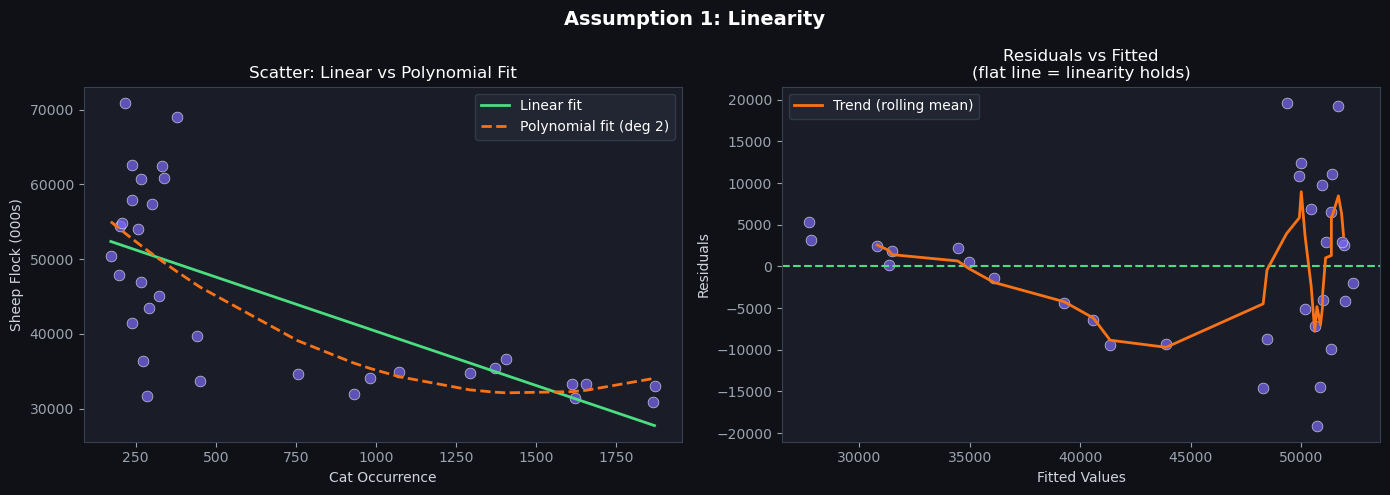

In [ ]:
df = pd.read_csv('../datasets/farm_cat.csv')
aus = df[df['territory'] == 'All Australia'].copy()
aus = aus.sort_values('year').dropna(subset=['cats_occurrence_total', 'sheep_flock'])

X = aus['cats_occurrence_total'].values.reshape(-1, 1)
y = aus['sheep_flock'].values

lin = LinearRegression().fit(X, y)
y_pred_lin = lin.predict(X)
residuals = y - y_pred_lin

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
pol = LinearRegression().fit(X_poly, y)
y_pred_poly = pol.predict(X_poly)

DARK, CARD = '#0f1117', '#1a1d27'
A1, A2, A3 = '#7c6af7', '#4ade80', '#f97316'

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=DARK)
fig.suptitle('Assumption 1: Linearity', fontsize=14, color='white', fontweight='bold')

for ax in axes:
    ax.set_facecolor(CARD)
    ax.tick_params(colors='#9ca3af')
    ax.xaxis.label.set_color('#d1d5db')
    ax.yaxis.label.set_color('#d1d5db')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#374151')

ax = axes[0]
ax.scatter(X, y, color=A1, alpha=0.7, s=60, edgecolors='white', linewidth=0.5)
sort_idx = X.flatten().argsort()
ax.plot(X[sort_idx], y_pred_lin[sort_idx], color=A2, linewidth=2, label='Linear fit')
ax.plot(X[sort_idx], y_pred_poly[sort_idx], color=A3, linewidth=2,
        linestyle='--', label='Polynomial fit (deg 2)')
ax.set_xlabel('Cat Occurrence')
ax.set_ylabel('Sheep Flock (000s)')
ax.set_title('Scatter: Linear vs Polynomial Fit')
ax.legend(facecolor='#252836', edgecolor='#374151', labelcolor='white')

ax = axes[1]
ax.scatter(y_pred_lin, residuals, color=A1, alpha=0.7, s=60,
           edgecolors='white', linewidth=0.5)
ax.axhline(0, color=A2, linewidth=1.5, linestyle='--')
sort_idx2 = y_pred_lin.argsort()
ax.plot(np.sort(y_pred_lin),
        pd.Series(residuals[sort_idx2]).rolling(5, center=True).mean(),
        color=A3, linewidth=2, label='Trend (rolling mean)')
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted\n(flat line = linearity holds)')
ax.legend(facecolor='#252836', edgecolor='#374151', labelcolor='white')

plt.tight_layout()
plt.savefig('1_linearity.png', dpi=150,
            bbox_inches='tight', facecolor=DARK)
print(f"Linear R²:     {lin.score(X, y):.4f}")
print(f"Polynomial R²: {pol.score(X_poly, y):.4f}")
print("If polynomial R² >> linear R², linearity may be violated.")

### Autocorrelation

Durbin-Watson: 0.3348
Interpretation: ~2 = no autocorrelation | <1.5 = positive | >2.5 = negative


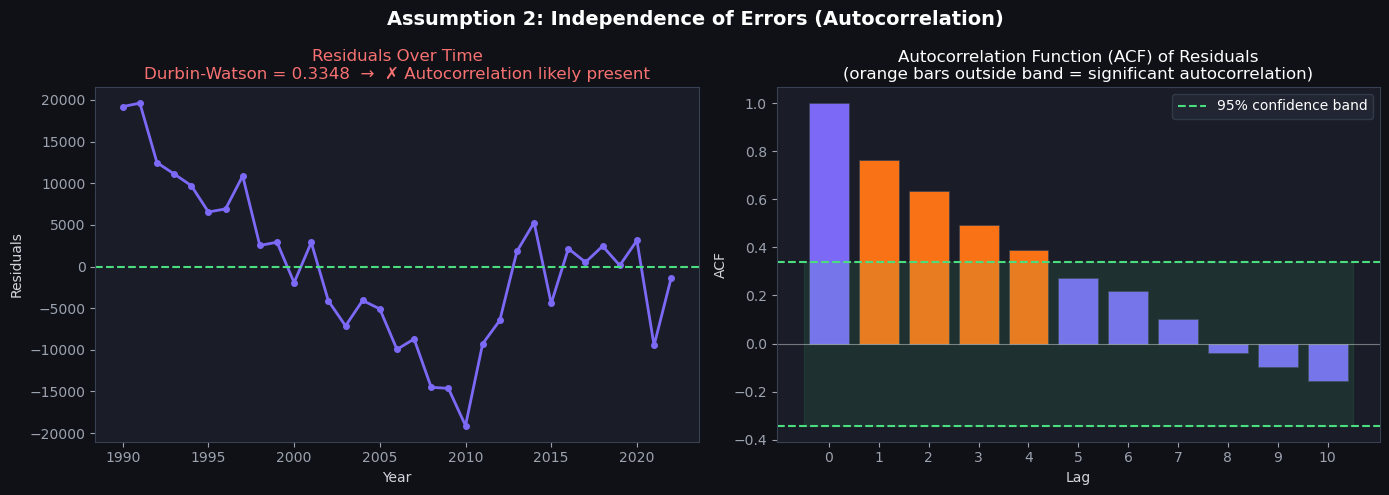

In [ ]:

df = pd.read_csv('../datasets/farm_cat.csv')
aus = df[df['territory'] == 'All Australia'].copy()
aus = aus.sort_values('year').dropna(subset=['cats_occurrence_total', 'sheep_flock'])

X = aus['cats_occurrence_total'].values.reshape(-1, 1)
y = aus['sheep_flock'].values
residuals = y - LinearRegression().fit(X, y).predict(X)

dw = np.sum(np.diff(residuals) ** 2) / np.sum(residuals ** 2)

def acf(x, nlags=10):
    n = len(x)
    xd = x - x.mean()
    var = np.dot(xd, xd) / n
    return [np.dot(xd[:n-lag], xd[lag:]) / n / var if lag < n else 0
            for lag in range(nlags + 1)]

lags_range = 10
acf_vals = np.array(acf(residuals, nlags=lags_range))
conf = 1.96 / np.sqrt(len(residuals))

DARK, CARD = '#0f1117', '#1a1d27'
A1, A2, A3 = '#7c6af7', '#4ade80', '#f97316'

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=DARK)
fig.suptitle('Assumption 2: Independence of Errors (Autocorrelation)',
             fontsize=14, color='white', fontweight='bold')

for ax in axes:
    ax.set_facecolor(CARD)
    ax.tick_params(colors='#9ca3af')
    ax.xaxis.label.set_color('#d1d5db')
    ax.yaxis.label.set_color('#d1d5db')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#374151')

ax = axes[0]
ax.plot(aus['year'].values, residuals, color=A1, linewidth=2, marker='o', markersize=4)
ax.axhline(0, color=A2, linewidth=1.5, linestyle='--')
verdict = "✓ No strong autocorrelation" if 1.5 < dw < 2.5 else "✗ Autocorrelation likely present"
v_color = '#4ade80' if 1.5 < dw < 2.5 else '#f87171'
ax.set_title(f'Residuals Over Time\nDurbin-Watson = {dw:.4f}  →  {verdict}')
ax.title.set_color(v_color)
ax.set_xlabel('Year')
ax.set_ylabel('Residuals')

ax = axes[1]
lags = np.arange(lags_range + 1)
bar_colors = [A3 if abs(v) > conf and i > 0 else A1 for i, v in enumerate(acf_vals)]
ax.bar(lags, acf_vals, color=bar_colors, edgecolor='#374151', linewidth=0.5)
ax.axhline( conf, color=A2, linewidth=1.5, linestyle='--', label='95% confidence band')
ax.axhline(-conf, color=A2, linewidth=1.5, linestyle='--')
ax.fill_between([-0.5, lags_range + 0.5], -conf, conf, alpha=0.1, color=A2)
ax.axhline(0, color='white', linewidth=0.8, alpha=0.4)
ax.set_xticks(lags)
ax.set_xlabel('Lag')
ax.set_ylabel('ACF')
ax.set_title('Autocorrelation Function (ACF) of Residuals\n'
             '(orange bars outside band = significant autocorrelation)')
ax.legend(facecolor='#252836', edgecolor='#374151', labelcolor='white')

plt.tight_layout()
plt.savefig('2_autocorrelation.png', dpi=150,
            bbox_inches='tight', facecolor=DARK)
print(f"Durbin-Watson: {dw:.4f}")
print("Interpretation: ~2 = no autocorrelation | <1.5 = positive | >2.5 = negative")

### Homoscedasticity

Breusch-Pagan LM: 5.0451, p=0.0247
If p < 0.05: heteroscedasticity present (violation).


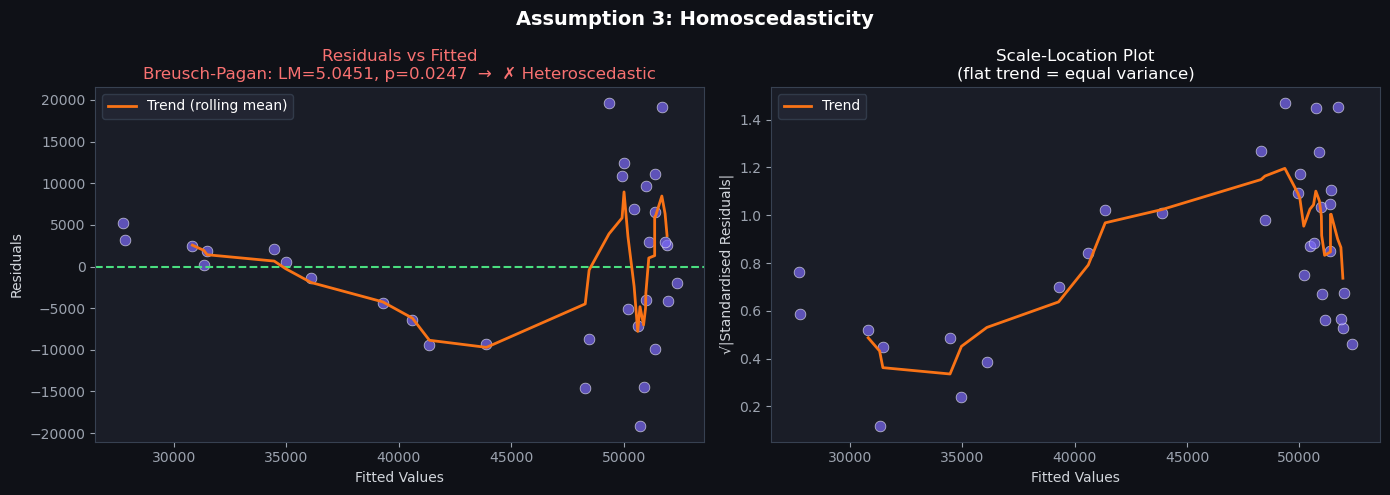

In [ ]:
df = pd.read_csv('../datasets/farm_cat.csv')
aus = df[df['territory'] == 'All Australia'].copy()
aus = aus.sort_values('year').dropna(subset=['cats_occurrence_total', 'sheep_flock'])

X = aus['cats_occurrence_total'].values.reshape(-1, 1)
y = aus['sheep_flock'].values
lin = LinearRegression().fit(X, y)
y_pred = lin.predict(X)
residuals = y - y_pred

resid_sq = residuals ** 2
X_bp = np.column_stack([np.ones(len(X)), X.flatten()])
beta = np.linalg.lstsq(X_bp, resid_sq, rcond=None)[0]
resid_sq_pred = X_bp @ beta
ss_res = np.sum((resid_sq - resid_sq_pred) ** 2)
ss_tot = np.sum((resid_sq - resid_sq.mean()) ** 2)
r2_bp = 1 - ss_res / ss_tot
n = len(y)
bp_lm = n * r2_bp
bp_p  = 1 - stats.chi2.cdf(bp_lm, df=1)

DARK, CARD = '#0f1117', '#1a1d27'
A1, A2, A3 = '#7c6af7', '#4ade80', '#f97316'

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=DARK)
fig.suptitle('Assumption 3: Homoscedasticity', fontsize=14,
             color='white', fontweight='bold')

for ax in axes:
    ax.set_facecolor(CARD)
    ax.tick_params(colors='#9ca3af')
    ax.xaxis.label.set_color('#d1d5db')
    ax.yaxis.label.set_color('#d1d5db')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#374151')

ax = axes[0]
ax.scatter(y_pred, residuals, color=A1, alpha=0.7, s=60,
           edgecolors='white', linewidth=0.5)
ax.axhline(0, color=A2, linewidth=1.5, linestyle='--')
sort_idx = y_pred.argsort()
ax.plot(np.sort(y_pred),
        pd.Series(residuals[sort_idx]).rolling(5, center=True).mean(),
        color=A3, linewidth=2, label='Trend (rolling mean)')
verdict = "✓ Homoscedastic" if bp_p > 0.05 else "✗ Heteroscedastic"
v_color = '#4ade80' if bp_p > 0.05 else '#f87171'
ax.set_title(f'Residuals vs Fitted\nBreusch-Pagan: LM={bp_lm:.4f}, p={bp_p:.4f}  →  {verdict}')
ax.title.set_color(v_color)
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')
ax.legend(facecolor='#252836', edgecolor='#374151', labelcolor='white')

ax = axes[1]
std_resid = residuals / residuals.std()
ax.scatter(y_pred, np.sqrt(np.abs(std_resid)), color=A1, alpha=0.7,
           s=60, edgecolors='white', linewidth=0.5)
ax.plot(np.sort(y_pred),
        pd.Series(np.sqrt(np.abs(std_resid))[sort_idx]).rolling(5, center=True).mean(),
        color=A3, linewidth=2, label='Trend')
ax.set_xlabel('Fitted Values')
ax.set_ylabel('√|Standardised Residuals|')
ax.set_title('Scale-Location Plot\n(flat trend = equal variance)')
ax.legend(facecolor='#252836', edgecolor='#374151', labelcolor='white')

plt.tight_layout()
plt.savefig('3_homoscedasticity.png', dpi=150,
            bbox_inches='tight', facecolor=DARK)
print(f"Breusch-Pagan LM: {bp_lm:.4f}, p={bp_p:.4f}")
print("If p < 0.05: heteroscedasticity present (violation).")

### Normality

Shapiro-Wilk: W=0.9848, p=0.9130
KS test:      stat=0.0928, p=0.9135
If p < 0.05: residuals are not normally distributed (violation).


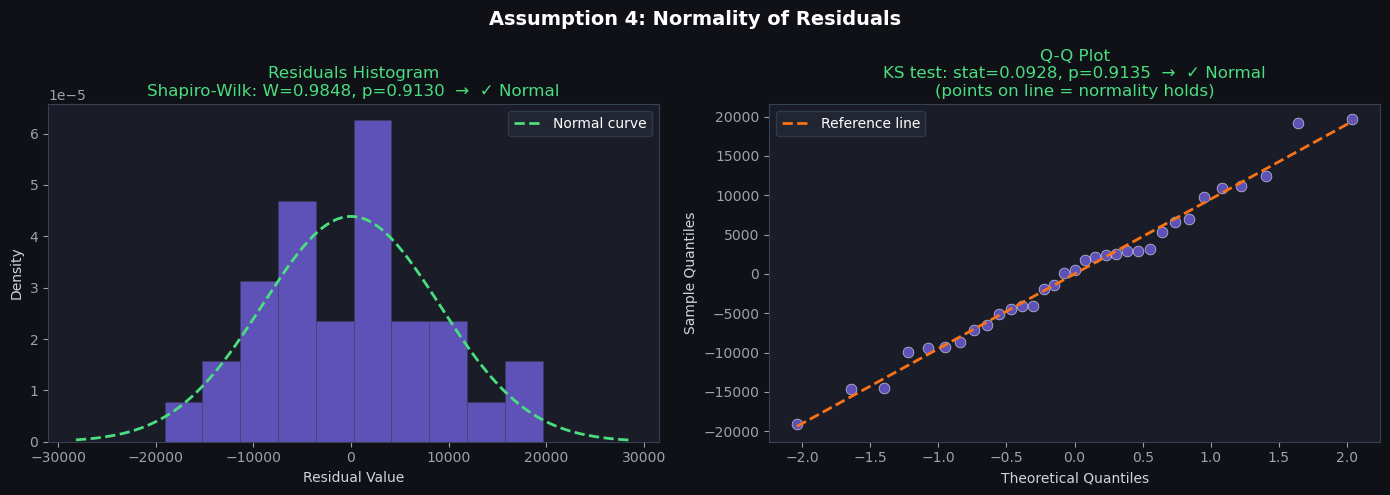

In [ ]:
df = pd.read_csv('../datasets/farm_cat.csv')
aus = df[df['territory'] == 'All Australia'].copy()
aus = aus.sort_values('year').dropna(subset=['cats_occurrence_total', 'sheep_flock'])

X = aus['cats_occurrence_total'].values.reshape(-1, 1)
y = aus['sheep_flock'].values

residuals = y - LinearRegression().fit(X, y).predict(X)

sw_stat, sw_p   = stats.shapiro(residuals)
ks_stat, ks_p   = stats.kstest(residuals, 'norm',
                                args=(residuals.mean(), residuals.std()))

DARK, CARD = '#0f1117', '#1a1d27'
A1, A2, A3 = '#7c6af7', '#4ade80', '#f97316'

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=DARK)
fig.suptitle('Assumption 4: Normality of Residuals', fontsize=14,
             color='white', fontweight='bold')

for ax in axes:
    ax.set_facecolor(CARD)
    ax.tick_params(colors='#9ca3af')
    ax.xaxis.label.set_color('#d1d5db')
    ax.yaxis.label.set_color('#d1d5db')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#374151')

ax = axes[0]
ax.hist(residuals, bins=10, density=True, color=A1, alpha=0.7,
        edgecolor='#374151', linewidth=0.5)
x_line = np.linspace(residuals.min() - residuals.std(),
                     residuals.max() + residuals.std(), 200)
ax.plot(x_line, stats.norm.pdf(x_line, residuals.mean(), residuals.std()),
        color=A2, linewidth=2, linestyle='--', label='Normal curve')
sw_verdict = "✓ Normal" if sw_p > 0.05 else "✗ Non-normal"
sw_color   = '#4ade80' if sw_p > 0.05 else '#f87171'
ax.set_title(f'Residuals Histogram\nShapiro-Wilk: W={sw_stat:.4f}, p={sw_p:.4f}  →  {sw_verdict}')
ax.title.set_color(sw_color)
ax.set_xlabel('Residual Value')
ax.set_ylabel('Density')
ax.legend(facecolor='#252836', edgecolor='#374151', labelcolor='white')

ax = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
ax.scatter(osm, osr, color=A1, alpha=0.7, s=60, edgecolors='white', linewidth=0.5)
ax.plot(osm, slope * np.array(osm) + intercept, color=A3,
        linewidth=2, linestyle='--', label='Reference line')
ks_verdict = "✓ Normal" if ks_p > 0.05 else "✗ Non-normal"
ks_color   = '#4ade80' if ks_p > 0.05 else '#f87171'
ax.set_title(f'Q-Q Plot\nKS test: stat={ks_stat:.4f}, p={ks_p:.4f}  →  {ks_verdict}\n'
             f'(points on line = normality holds)')
ax.title.set_color(ks_color)
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')
ax.legend(facecolor='#252836', edgecolor='#374151', labelcolor='white')

plt.tight_layout()
plt.savefig('4_normality.png', dpi=150,
            bbox_inches='tight', facecolor=DARK)
print(f"Shapiro-Wilk: W={sw_stat:.4f}, p={sw_p:.4f}")
print(f"KS test:      stat={ks_stat:.4f}, p={ks_p:.4f}")
print("If p < 0.05: residuals are not normally distributed (violation).")

### Outliers


Cook's Distance threshold (4/n): 0.1212
Influential years: []

Top 5 Cook's D:
  1990: 0.1164
  2010: 0.1018
  1991: 0.0914
  2008: 0.0599
  2009: 0.0458


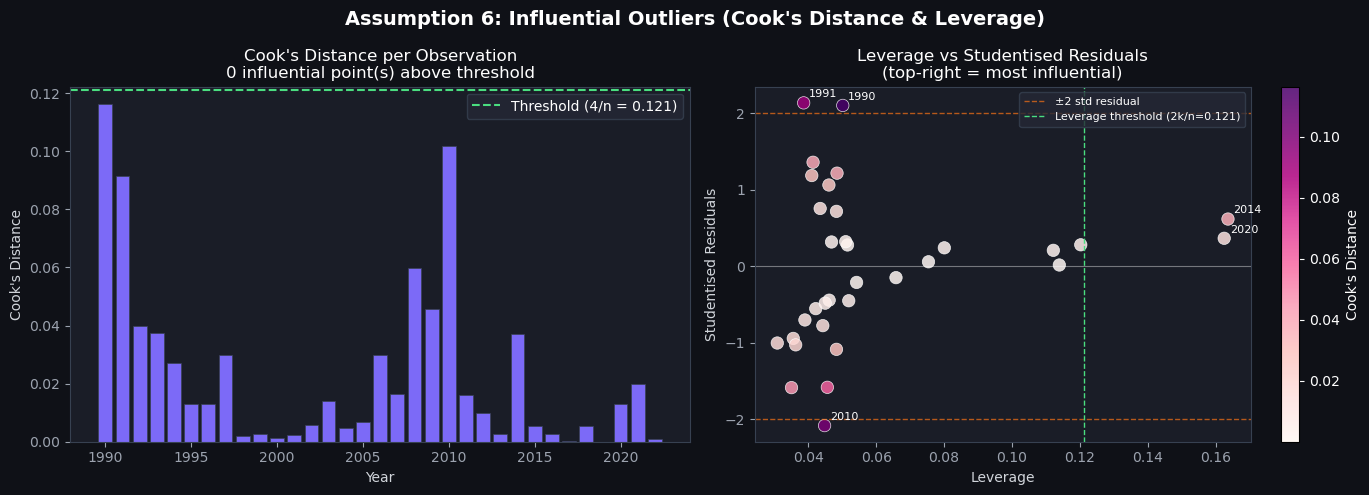

In [ ]:
df = pd.read_csv('../datasets/farm_cat.csv')
aus = df[df['territory'] == 'All Australia'].copy()
aus = aus.sort_values('year').dropna(subset=['cats_occurrence_total', 'sheep_flock'])

X_raw = aus['cats_occurrence_total'].values
y = aus['sheep_flock'].values
years = aus['year'].values
n = len(y)

X_mat = np.column_stack([np.ones(n), X_raw])

beta = np.linalg.lstsq(X_mat, y, rcond=None)[0]
y_pred = X_mat @ beta
residuals = y - y_pred

H = X_mat @ np.linalg.inv(X_mat.T @ X_mat) @ X_mat.T
leverage = np.diag(H)

mse = np.sum(residuals ** 2) / (n - 2)
std_resid = residuals / np.sqrt(mse * (1 - leverage))

k = 2
cooks_d = (std_resid ** 2 / k) * (leverage / (1 - leverage))

threshold = 4 / n

DARK, CARD = '#0f1117', '#1a1d27'
A1, A2, A3 = '#7c6af7', '#4ade80', '#f97316'

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=DARK)
fig.suptitle("Assumption 6: Influential Outliers (Cook's Distance & Leverage)",
             fontsize=14, color='white', fontweight='bold')

for ax in axes:
    ax.set_facecolor(CARD)
    ax.tick_params(colors='#9ca3af')
    ax.xaxis.label.set_color('#d1d5db')
    ax.yaxis.label.set_color('#d1d5db')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#374151')

ax = axes[0]
colors = [A3 if d > threshold else A1 for d in cooks_d]
ax.bar(years, cooks_d, color=colors, edgecolor='#374151', linewidth=0.5)
ax.axhline(threshold, color=A2, linewidth=1.5, linestyle='--',
           label=f'Threshold (4/n = {threshold:.3f})')
for yr, d in zip(years, cooks_d):
    if d > threshold:
        ax.annotate(str(yr), (yr, d), textcoords='offset points',
                    xytext=(0, 5), ha='center', color='white', fontsize=8)
n_inf = sum(d > threshold for d in cooks_d)
ax.set_xlabel('Year')
ax.set_ylabel("Cook's Distance")
ax.set_title(f"Cook's Distance per Observation\n{n_inf} influential point(s) above threshold")
ax.legend(facecolor='#252836', edgecolor='#374151', labelcolor='white')

ax = axes[1]
sc = ax.scatter(leverage, std_resid, c=cooks_d, cmap='RdPu',
                s=80, edgecolors='white', linewidth=0.5, alpha=0.85)
ax.axhline(0,  color='white', linewidth=0.8, alpha=0.4)
ax.axhline( 2, color=A3, linewidth=1, linestyle='--', alpha=0.7)
ax.axhline(-2, color=A3, linewidth=1, linestyle='--', alpha=0.7, label='±2 std residual')
lev_thresh = 2 * k / n
ax.axvline(lev_thresh, color=A2, linewidth=1, linestyle='--',
           label=f'Leverage threshold (2k/n={lev_thresh:.3f})')
for lev, res, yr in zip(leverage, std_resid, years):
    if abs(res) > 2 or lev > lev_thresh:
        ax.annotate(str(yr), (lev, res), textcoords='offset points',
                    xytext=(4, 4), fontsize=8, color='white')
cb = plt.colorbar(sc, ax=ax, label="Cook's Distance")
cb.ax.yaxis.label.set_color('white')
cb.ax.tick_params(colors='white')
ax.set_xlabel('Leverage')
ax.set_ylabel('Studentised Residuals')
ax.set_title('Leverage vs Studentised Residuals\n(top-right = most influential)')
ax.legend(facecolor='#252836', edgecolor='#374151', labelcolor='white', fontsize=8)

plt.tight_layout()
plt.savefig('5_outliers.png', dpi=150,
            bbox_inches='tight', facecolor=DARK)
print(f"\nCook's Distance threshold (4/n): {threshold:.4f}")
print(f"Influential years: {[years[i] for i, d in enumerate(cooks_d) if d > threshold]}")
print(f"\nTop 5 Cook's D:")
for yr, d in sorted(zip(years, cooks_d), key=lambda x: -x[1])[:5]:
    print(f"  {yr}: {d:.4f}")

# KS-test


2-Sample KS (cats vs sheep): stat=0.2121, p=0.4535
1-Sample KS normality - Cats:  stat=0.2903, p=0.0059
1-Sample KS normality - Sheep: stat=0.2080, p=0.0991


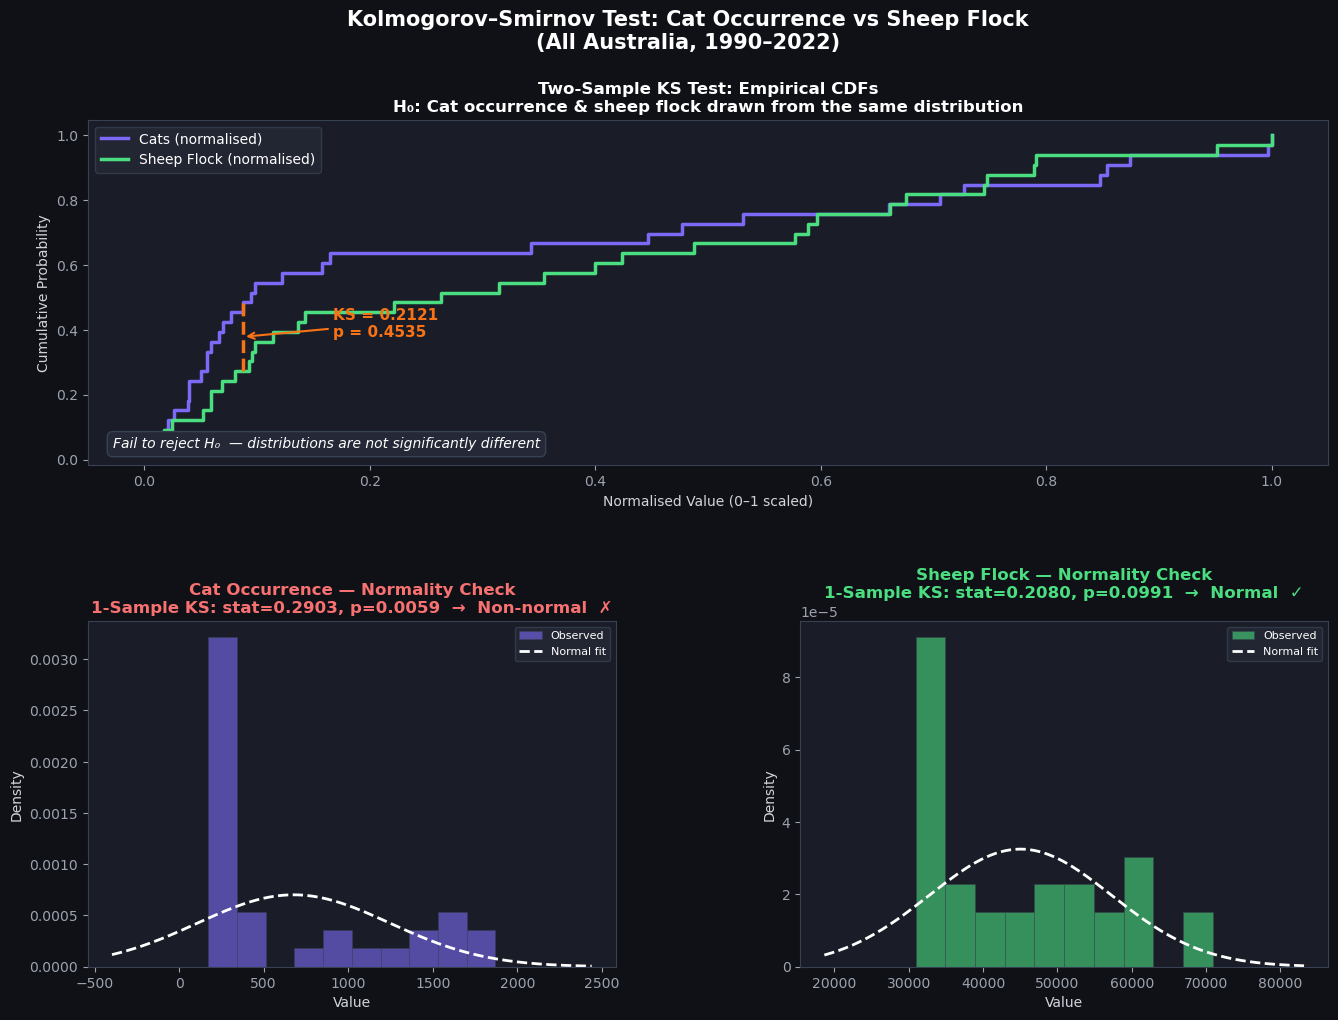

In [ ]:
df = pd.read_csv('../datasets/farm_cat.csv')
aus = df[df['territory'] == 'All Australia'].copy()
aus = aus.sort_values('year').dropna(subset=['cats_occurrence_total', 'sheep_flock'])

cats = aus['cats_occurrence_total'].values
sheep = aus['sheep_flock'].values

cats_norm = (cats - cats.min()) / (cats.max() - cats.min())
sheep_norm = (sheep - sheep.min()) / (sheep.max() - sheep.min())


ks2_stat, ks2_p = stats.ks_2samp(cats_norm, sheep_norm)

cats_ks, cats_p = stats.kstest(cats, 'norm', args=(cats.mean(), cats.std()))
sheep_ks, sheep_p = stats.kstest(sheep, 'norm', args=(sheep.mean(), sheep.std()))

DARK  = '#0f1117'
CARD  = '#1a1d27'
A1    = '#7c6af7'   # purple - cats
A2    = '#4ade80'   # green  - sheep
A3    = '#f97316'   # orange - KS gap

fig = plt.figure(figsize=(16, 11), facecolor=DARK)
fig.suptitle('Kolmogorov–Smirnov Test: Cat Occurrence vs Sheep Flock\n(All Australia, 1990–2022)',
             fontsize=15, color='white', fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)
ax1 = fig.add_subplot(gs[0, :])   # main KS plot (full width)
ax2 = fig.add_subplot(gs[1, 0])   # cats normality
ax3 = fig.add_subplot(gs[1, 1])   # sheep normality

def style(ax):
    ax.set_facecolor(CARD)
    ax.tick_params(colors='#9ca3af')
    ax.xaxis.label.set_color('#d1d5db')
    ax.yaxis.label.set_color('#d1d5db')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#374151')

for ax in [ax1, ax2, ax3]:
    style(ax)

cats_sorted  = np.sort(cats_norm)
sheep_sorted = np.sort(sheep_norm)

ecdf_cats  = np.arange(1, len(cats_sorted)  + 1) / len(cats_sorted)
ecdf_sheep = np.arange(1, len(sheep_sorted) + 1) / len(sheep_sorted)

ax1.step(cats_sorted,  ecdf_cats,  where='post', color=A1, linewidth=2.5, label='Cats (normalised)')
ax1.step(sheep_sorted, ecdf_sheep, where='post', color=A2, linewidth=2.5, label='Sheep Flock (normalised)')

all_x = np.concatenate([cats_sorted, sheep_sorted])
ecdf_c_at_x = np.searchsorted(cats_sorted,  all_x, side='right') / len(cats_sorted)
ecdf_s_at_x = np.searchsorted(sheep_sorted, all_x, side='right') / len(sheep_sorted)
diffs = np.abs(ecdf_c_at_x - ecdf_s_at_x)
max_idx = np.argmax(diffs)
x_gap = all_x[max_idx]
y_c   = ecdf_c_at_x[max_idx]
y_s   = ecdf_s_at_x[max_idx]

ax1.vlines(x_gap, min(y_c, y_s), max(y_c, y_s),
           color=A3, linewidth=2.5, linestyle='--', zorder=5)
ax1.annotate(f'KS = {ks2_stat:.4f}\np = {ks2_p:.4f}',
             xy=(x_gap, (y_c + y_s) / 2),
             xytext=(x_gap + 0.08, (y_c + y_s) / 2),
             color=A3, fontsize=11, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=A3, lw=1.5))

ax1.set_xlabel('Normalised Value (0–1 scaled)')
ax1.set_ylabel('Cumulative Probability')
ax1.set_title('Two-Sample KS Test: Empirical CDFs\n'
              'H₀: Cat occurrence & sheep flock drawn from the same distribution',
              fontweight='bold')
ax1.legend(facecolor='#252836', edgecolor='#374151', labelcolor='white')

verdict = "Fail to reject H₀  — distributions are not significantly different" if ks2_p > 0.05 \
          else "Reject H₀  — distributions are significantly different"
ax1.text(0.02, 0.05, verdict, transform=ax1.transAxes,
         color='white', fontsize=10, style='italic',
         bbox=dict(facecolor='#252836', edgecolor='#374151', boxstyle='round,pad=0.4'))

def normality_plot(ax, data, color, label, ks, p):
    x = np.linspace(data.min() - data.std(), data.max() + data.std(), 200)
    mu, sigma = data.mean(), data.std()
    normal_pdf = stats.norm.pdf(x, mu, sigma)

    ax.hist(data, bins=10, density=True, color=color, alpha=0.6,
            edgecolor='#374151', linewidth=0.5, label='Observed')
    ax.plot(x, normal_pdf, color='white', linewidth=2, linestyle='--', label='Normal fit')

    verdict = "Normal  ✓" if p > 0.05 else "Non-normal  ✗"
    v_color = '#4ade80' if p > 0.05 else '#f87171'
    ax.set_title(f'{label}\n1-Sample KS: stat={ks:.4f}, p={p:.4f}  →  {verdict}',
                 fontweight='bold', color='white')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(facecolor='#252836', edgecolor='#374151', labelcolor='white', fontsize=8)
    ax.title.set_color(v_color)

normality_plot(ax2, cats,  A1, 'Cat Occurrence — Normality Check',  cats_ks,  cats_p)
normality_plot(ax3, sheep, A2, 'Sheep Flock — Normality Check',     sheep_ks, sheep_p)

plt.savefig('ks_test.png',
            dpi=150, bbox_inches='tight', facecolor=DARK)
print(f"\n2-Sample KS (cats vs sheep): stat={ks2_stat:.4f}, p={ks2_p:.4f}")
print(f"1-Sample KS normality - Cats:  stat={cats_ks:.4f}, p={cats_p:.4f}")
print(f"1-Sample KS normality - Sheep: stat={sheep_ks:.4f}, p={sheep_p:.4f}")

# Realtime analysis

In [2]:
df = pd.read_csv("../datasets/farm_cat.csv")
# df = df[df["territory"] == "All Australia"] # this line destroys our analysis, it went from R2 = 0.925 to 0.191

# df = df[~df["territory"].str.contains("All Australia", case=False, na=False)]


Null count

In [3]:
print(df.isnull().sum())

year                      0
territory                 0
lambs                    14
rams                     14
ewes                     14
lamb_sheep_shorn          0
sheep_flock               0
sheep_purchased           0
cats_occurrence_total    42
cats_forest              42
dtype: int64


# Visualizing patterns count plot, historgram with kde distr, and scatter plot

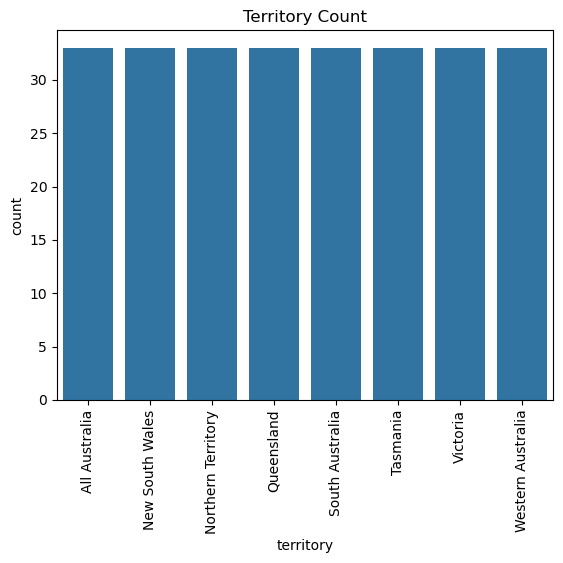

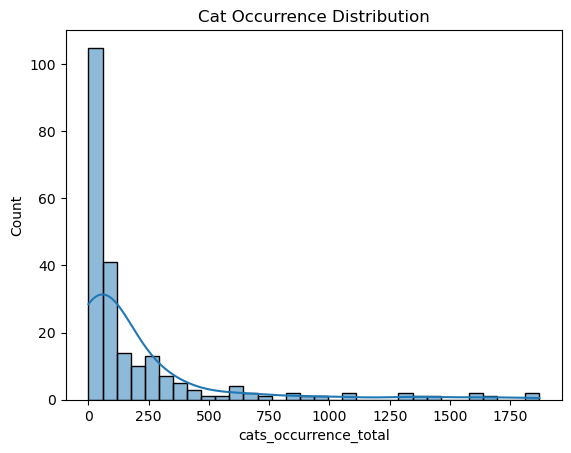

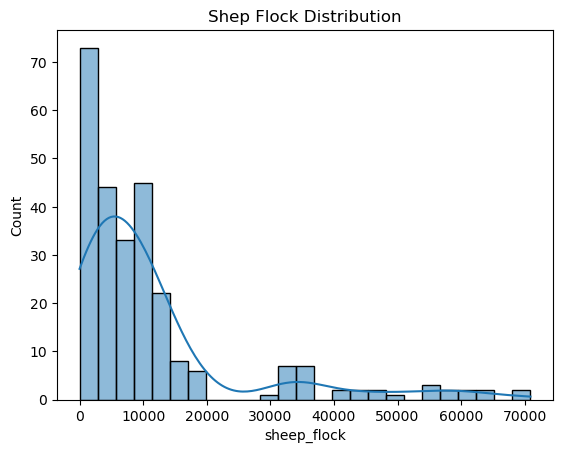

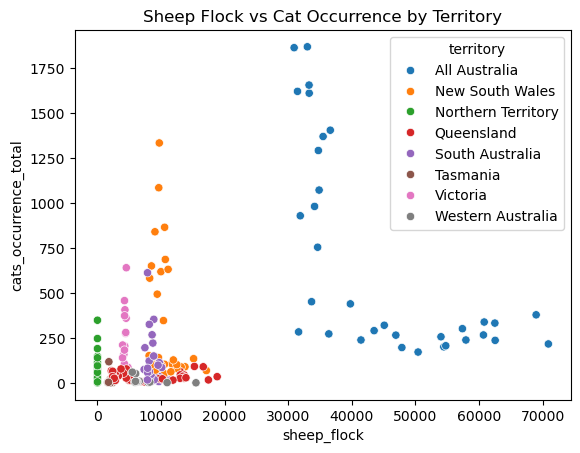

In [ ]:

sns.countplot(x='territory', data=df)
plt.title("Territory Count")
plt.xticks(rotation=90)
plt.show()

sns.histplot(df['cats_occurrence_total'], kde=True)
plt.title("Cat Occurrence Distribution") # Log scaled
plt.show()

sns.histplot(df['sheep_flock'], kde=True)
plt.title("Shep Flock Distribution") # Log scaled
plt.show()

sns.scatterplot(x='sheep_flock', y='cats_occurrence_total', hue='territory', data=df)
plt.title("Sheep Flock vs Cat Occurrence by Territory")
plt.show()

#### We see that both cats and sheep flock are log scaled distributions so we'll use log scale

In [12]:
df["log_sheep"] = np.log1p(df["sheep_purchased"])
df["log_cats"] = np.log1p(df["cats_occurrence_total"])

Text(0.5, 1.0, 'Log Cat and Sheep Scatter by territory (incl AllAus)')

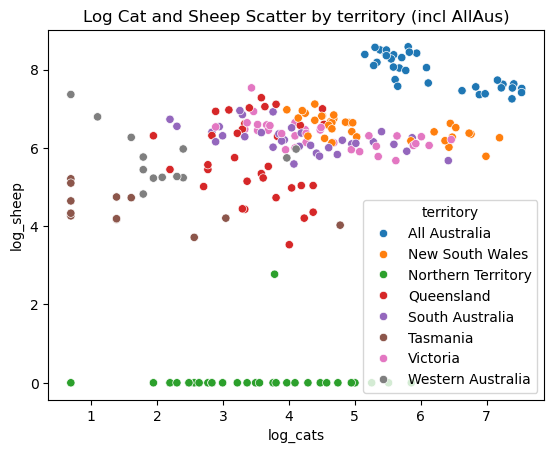

In [ ]:
sns.scatterplot(x=df['log_cats'], y=df['log_sheep'], hue='territory', data=df)
plt.title('Log-scaled Cat and Sheep Scatter')

## Linear Regression Model: Two sets - All territories and by territory

In [5]:
df_reg = df[["sheep_flock", "cats_occurrence_total"]].copy()

imputer = SimpleImputer(strategy="mean")
df_reg_imputed = pd.DataFrame(imputer.fit_transform(df_reg), columns=df_reg.columns)
df_reg_imputed.head()

,sheep_flock,cats_occurrence_total
0,70896.0,217.0
1,17123.0,69.0
2,4.0,43.0
3,17443.0,17.0
4,10952.0,26.0


In [6]:
X = df_reg_imputed[["cats_occurrence_total"]]
y = df_reg_imputed["sheep_flock"]


In [7]:
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2   = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"  Coefficient: {model.coef_[0]:,.4f}")
print(f"  R²         : {r2:.4f}")
print(f"  RMSE       : {rmse:,.2f}")

  Coefficient: 18.0429
  R²         : 0.1629
  RMSE       : 12,993.59


### Linear Regression with more variables

This ones for all territories, we only imputed numerical columns

In [14]:
df_reg = df[["sheep_purchased", "cats_occurrence_total", "year", "territory"]].copy()

# Numeric and categorical separation
numeric_cols = ["sheep_purchased", "cats_occurrence_total", "year"]
categorical_cols = ["territory"]

# Imputing numeric only
imputer = SimpleImputer(strategy="mean")
df_numeric_imputed = pd.DataFrame(
    imputer.fit_transform(df_reg[numeric_cols]),
    columns=numeric_cols
)

# Add territory back
df_numeric_imputed["territory"] = df_reg["territory"].values

# Encode territory
df_encoded = pd.get_dummies(
    df_numeric_imputed,
    columns=["territory"],
    drop_first=True
)

X = df_encoded.drop(columns=["sheep_purchased"])
y = df_encoded["sheep_purchased"]

In [15]:
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2   = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"  Coefficient: {model.coef_[0]:,.4f}")
print(f"  R²         : {r2:.4f}")
print(f"  RMSE       : {rmse:,.2f}")

  Coefficient: -0.8122
  R²         : 0.8666
  RMSE       : 380.90


This one is for modelling for separate territories

In [ ]:
for territory in df["territory"].unique():
    # Filter territory
    df_t = df[df["territory"] == territory]

    df_reg = df_t[["sheep_purchased", "cats_occurrence_total", "year"]].copy()

    # Impute
    imputer = SimpleImputer(strategy="mean")
    df_reg_imputed = pd.DataFrame(
        imputer.fit_transform(df_reg),
        columns=df_reg.columns
    )

    X = df_reg_imputed.drop(columns=["sheep_purchased"])
    y = df_reg_imputed["sheep_purchased"]

    model = LinearRegression()
    model.fit(X, y)

    r2 = model.score(X, y)

    print(f"Territory: {territory}")
    print("Intercept:", model.intercept_)
    print(f"  Coefficient: {model.coef_[0]:,.4f}")
    print(f"  R²         : {r2:.4f}")
    print(f"  RMSE       : {rmse:,.2f}")

All Australia
R²: 0.808
Intercept: 234587.0960127459
  Coefficient: -0.0585
  R²         : 0.8076
  RMSE       : 1,163.08
New South Wales
R²: 0.418
Intercept: 19226.934444490973
  Coefficient: -0.1674
  R²         : 0.4176
  RMSE       : 1,163.08
Northern Territory
R²: 0.091
Intercept: 169.66544375303326
  Coefficient: 0.0017
  R²         : 0.0907
  RMSE       : 1,163.08
Queensland
R²: 0.716
Intercept: 73474.4084844136
  Coefficient: -0.5803
  R²         : 0.7160
  RMSE       : 1,163.08
South Australia
R²: 0.570
Intercept: 31210.432802573658
  Coefficient: 0.0234
  R²         : 0.5703
  RMSE       : 1,163.08
Tasmania
R²: 0.194
Intercept: 5148.59543777287
  Coefficient: -0.2405
  R²         : 0.1936
  RMSE       : 1,163.08
Victoria
R²: 0.254
Intercept: 30144.903865262786
  Coefficient: 0.0291
  R²         : 0.2540
  RMSE       : 1,163.08
Western Australia
R²: 0.676
Intercept: 75115.84716819739
  Coefficient: 3.3115
  R²         : 0.6758
  RMSE       : 1,163.08


### $R^2$ ranking of the above:

\[
\begin{array}{l|c}
\text{Territory} & R^2 \\
\hline
\text{All Australia}      & 0.8076 \\
\text{Queensland}         & 0.7160 \\
\text{Western Australia}  & 0.6758 \\
\text{South Australia}    & 0.5703 \\
\text{New South Wales}    & 0.4176 \\
\text{Victoria}           & 0.2540 \\
\text{Tasmania}           & 0.1936 \\
\text{Northern Territory} & 0.0907 \\
\end{array}
\]

### Regressions by state (deletable)


In [13]:
results_territory = {}

In [14]:
df = pd.read_csv("../datasets/farm_cat.csv")
df = df[df["territory"] == "New South Wales"] # this line destroys our analysis, it went from R2 = 0.925 to 0.191

df_reg = df[["sheep_flock", "cats_occurrence_total", "year"]].copy()


imputer = SimpleImputer(strategy="mean")
df_reg_imputed = pd.DataFrame(imputer.fit_transform(df_reg), columns=df_reg.columns)
df_reg_imputed["territory"] = df["territory"]
df_encoded = pd.get_dummies(df_reg_imputed, columns=['territory'], drop_first=True)

X = df_encoded.drop(columns=["sheep_flock"])
y = df_encoded["sheep_flock"]


In [15]:
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2   = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("Intercept:", model.intercept_)
print(coef_df)
print(f"  Coefficient: {model.coef_[0]:,.4f}")
print(f"  R²         : {r2:.4f}")
print(f"  RMSE       : {rmse:,.2f}")

results_territory["New South Wales"] = {
    "intercept": model.intercept_,
    "coefficients": dict(zip(X.columns, model.coef_)),
    "r2": r2,
    "rmse": rmse
}

Intercept: 439225.04452959396
                 Feature  Coefficient
0  cats_occurrence_total     2.216945
1                   year  -213.933342
  Coefficient: 2.2169
  R²         : 0.6314
  RMSE       : 1,220.71


In [16]:
df = pd.read_csv("../datasets/farm_cat.csv")
df = df[df["territory"] == "Western Australia"] # this line destroys our analysis, it went from R2 = 0.925 to 0.191

df_reg = df[["sheep_flock", "cats_occurrence_total", "year"]].copy()


imputer = SimpleImputer(strategy="mean")
df_reg_imputed = pd.DataFrame(imputer.fit_transform(df_reg), columns=df_reg.columns)
df_reg_imputed["territory"] = df["territory"]
df_encoded = pd.get_dummies(df_reg_imputed, columns=['territory'], drop_first=True)

X = df_encoded.drop(columns=["sheep_flock"])
y = df_encoded["sheep_flock"]


In [17]:
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2   = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("Intercept:", model.intercept_)
print(coef_df)
print(f"  Coefficient: {model.coef_[0]:,.4f}")
print(f"  R²         : {r2:.4f}")
print(f"  RMSE       : {rmse:,.2f}")

results_territory["Western Australia"] = {
    "intercept": model.intercept_,
    "coefficients": dict(zip(X.columns, model.coef_)),
    "r2": r2,
    "rmse": rmse
}

Intercept: 873428.7527866664
                 Feature  Coefficient
0  cats_occurrence_total    26.041135
1                   year  -430.361646
  Coefficient: 26.0411
  R²         : 0.8938
  RMSE       : 1,392.71


In [18]:
df = pd.read_csv("../datasets/farm_cat.csv")
df = df[df["territory"] == "Tasmania"] # this line destroys our analysis, it went from R2 = 0.925 to 0.191

df_reg = df[["sheep_flock", "cats_occurrence_total", "year"]].copy()


imputer = SimpleImputer(strategy="mean")
df_reg_imputed = pd.DataFrame(imputer.fit_transform(df_reg), columns=df_reg.columns)
df_reg_imputed["territory"] = df["territory"]
df_encoded = pd.get_dummies(df_reg_imputed, columns=['territory'], drop_first=True)

X = df_encoded.drop(columns=["sheep_flock"])
y = df_encoded["sheep_flock"]


In [19]:
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2   = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("Intercept:", model.intercept_)
print(coef_df)
print(f"  Coefficient: {model.coef_[0]:,.4f}")
print(f"  R²         : {r2:.4f}")
print(f"  RMSE       : {rmse:,.2f}")

results_territory["Tasmania"] = {
    "intercept": model.intercept_,
    "coefficients": dict(zip(X.columns, model.coef_)),
    "r2": r2,
    "rmse": rmse
}

Intercept: 50633.74994815513
                 Feature  Coefficient
0  cats_occurrence_total     0.533081
1                   year   -24.201185
  Coefficient: 0.5331
  R²         : 0.5070
  RMSE       : 225.77


In [20]:
df = pd.read_csv("../datasets/farm_cat.csv")
print(df["territory"].unique())
df = df[df["territory"] == "Northern Territory"] # this line destroys our analysis, it went from R2 = 0.925 to 0.191

df_reg = df[["sheep_flock", "cats_occurrence_total", "year"]].copy()


imputer = SimpleImputer(strategy="mean")
df_reg_imputed = pd.DataFrame(imputer.fit_transform(df_reg), columns=df_reg.columns)
df_reg_imputed["territory"] = df["territory"]
df_encoded = pd.get_dummies(df_reg_imputed, columns=['territory'], drop_first=True)

X = df_encoded.drop(columns=["sheep_flock"])
y = df_encoded["sheep_flock"]


['All Australia' 'New South Wales' 'Northern Territory' 'Queensland'
 'South Australia' 'Tasmania' 'Victoria' 'Western Australia']


In [21]:
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2   = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("Intercept:", model.intercept_)
print(coef_df)
print(f"  Coefficient: {model.coef_[0]:,.4f}")
print(f"  R²         : {r2:.4f}")
print(f"  RMSE       : {rmse:,.2f}")

results_territory["Northern Territory"] = {
    "intercept": model.intercept_,
    "coefficients": dict(zip(X.columns, model.coef_)),
    "r2": r2,
    "rmse": rmse
}

Intercept: 157.59159427484556
                 Feature  Coefficient
0  cats_occurrence_total    -0.004884
1                   year    -0.077792
  Coefficient: -0.0049
  R²         : 0.0470
  RMSE       : 4.16


In [22]:
df = pd.read_csv("../datasets/farm_cat.csv")
df = df[df["territory"] == "Queensland"] # this line destroys our analysis, it went from R2 = 0.925 to 0.191

df_reg = df[["sheep_flock", "cats_occurrence_total", "year"]].copy()


imputer = SimpleImputer(strategy="mean")
df_reg_imputed = pd.DataFrame(imputer.fit_transform(df_reg), columns=df_reg.columns)
df_reg_imputed["territory"] = df["territory"]
df_encoded = pd.get_dummies(df_reg_imputed, columns=['territory'], drop_first=True)

X = df_encoded.drop(columns=["sheep_flock"])
y = df_encoded["sheep_flock"]


In [23]:
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2   = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("Intercept:", model.intercept_)
print(coef_df)
print(f"  Coefficient: {model.coef_[0]:,.4f}")
print(f"  R²         : {r2:.4f}")
print(f"  RMSE       : {rmse:,.2f}")

results_territory["Queensland"] = {
    "intercept": model.intercept_,
    "coefficients": dict(zip(X.columns, model.coef_)),
    "r2": r2,
    "rmse": rmse
}

Intercept: 1058298.495570299
                 Feature  Coefficient
0  cats_occurrence_total     5.613735
1                   year  -523.542194
  Coefficient: 5.6137
  R²         : 0.9067
  RMSE       : 1,600.13


In [24]:
df = pd.read_csv("../datasets/farm_cat.csv")
df = df[df["territory"] == "South Australia"] # this line destroys our analysis, it went from R2 = 0.925 to 0.191

df_reg = df[["sheep_flock", "cats_occurrence_total", "year"]].copy()


imputer = SimpleImputer(strategy="mean")
df_reg_imputed = pd.DataFrame(imputer.fit_transform(df_reg), columns=df_reg.columns)
df_reg_imputed["territory"] = df["territory"]
df_encoded = pd.get_dummies(df_reg_imputed, columns=['territory'], drop_first=True)

X = df_encoded.drop(columns=["sheep_flock"])
y = df_encoded["sheep_flock"]


In [25]:
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2   = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("Intercept:", model.intercept_)
print(coef_df)
print(f"  Coefficient: {model.coef_[0]:,.4f}")
print(f"  R²         : {r2:.4f}")
print(f"  RMSE       : {rmse:,.2f}")

results_territory["South Australia"] = {
    "intercept": model.intercept_,
    "coefficients": dict(zip(X.columns, model.coef_)),
    "r2": r2,
    "rmse": rmse
}

Intercept: 125688.19057159756
                 Feature  Coefficient
0  cats_occurrence_total    -0.043858
1                   year   -58.217545
  Coefficient: -0.0439
  R²         : 0.3331
  RMSE       : 788.71


In [26]:
df = pd.read_csv("../datasets/farm_cat.csv")
df = df[df["territory"] == "All Australia"] # this line destroys our analysis, it went from R2 = 0.925 to 0.191

df_reg = df[["sheep_flock", "cats_occurrence_total", "year"]].copy()


imputer = SimpleImputer(strategy="mean")
df_reg_imputed = pd.DataFrame(imputer.fit_transform(df_reg), columns=df_reg.columns)
df_reg_imputed["territory"] = df["territory"]
df_encoded = pd.get_dummies(df_reg_imputed, columns=['territory'], drop_first=True)

X = df_encoded.drop(columns=["sheep_flock"])
y = df_encoded["sheep_flock"]


In [27]:
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2   = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("Intercept:", model.intercept_)
print(coef_df)
print(f"  Coefficient: {model.coef_[0]:,.4f}")
print(f"  R²         : {r2:.4f}")
print(f"  RMSE       : {rmse:,.2f}")

results_territory["All Australia"] = {
    "intercept": model.intercept_,
    "coefficients": dict(zip(X.columns, model.coef_)),
    "r2": r2,
    "rmse": rmse
}

Intercept: 2962729.2572252103
                 Feature  Coefficient
0  cats_occurrence_total     5.037126
1                   year -1456.189828
  Coefficient: 5.0371
  R²         : 0.9077
  RMSE       : 3,730.41


In [28]:
results_territory

{'New South Wales': {'intercept': 439225.04452959396,
  'coefficients': {'cats_occurrence_total': 2.2169454438626066,
   'year': -213.93334158822415},
  'r2': 0.6313565980816733,
  'rmse': 1220.7089936787947},
 'Western Australia': {'intercept': 873428.7527866664,
  'coefficients': {'cats_occurrence_total': 26.04113484453956,
   'year': -430.3616456651688},
  'r2': 0.8937763857814218,
  'rmse': 1392.7134201591296},
 'Tasmania': {'intercept': 50633.74994815513,
  'coefficients': {'cats_occurrence_total': 0.5330810455458311,
   'year': -24.201184805162715},
  'r2': 0.5069966167690996,
  'rmse': 225.76702121635006},
 'Northern Territory': {'intercept': 157.59159427484556,
  'coefficients': {'cats_occurrence_total': -0.0048836001050010965,
   'year': -0.07779164981355434},
  'r2': 0.04698578330791514,
  'rmse': 4.16284535723601},
 'Queensland': {'intercept': 1058298.495570299,
  'coefficients': {'cats_occurrence_total': 5.61373465265882,
   'year': -523.5421940488318},
  'r2': 0.9066850513

# Lag regression


No lag:    r = -0.672, p = 0.0000
1-yr lag:  r = -0.649, p = 0.0001

Lag correlation table:
 lag         r        p
   0 -0.673471 0.000024
   1 -0.648693 0.000059
   2 -0.598541 0.000375
   3 -0.552449 0.001548
   4 -0.510753 0.004638
   5 -0.488797 0.008305


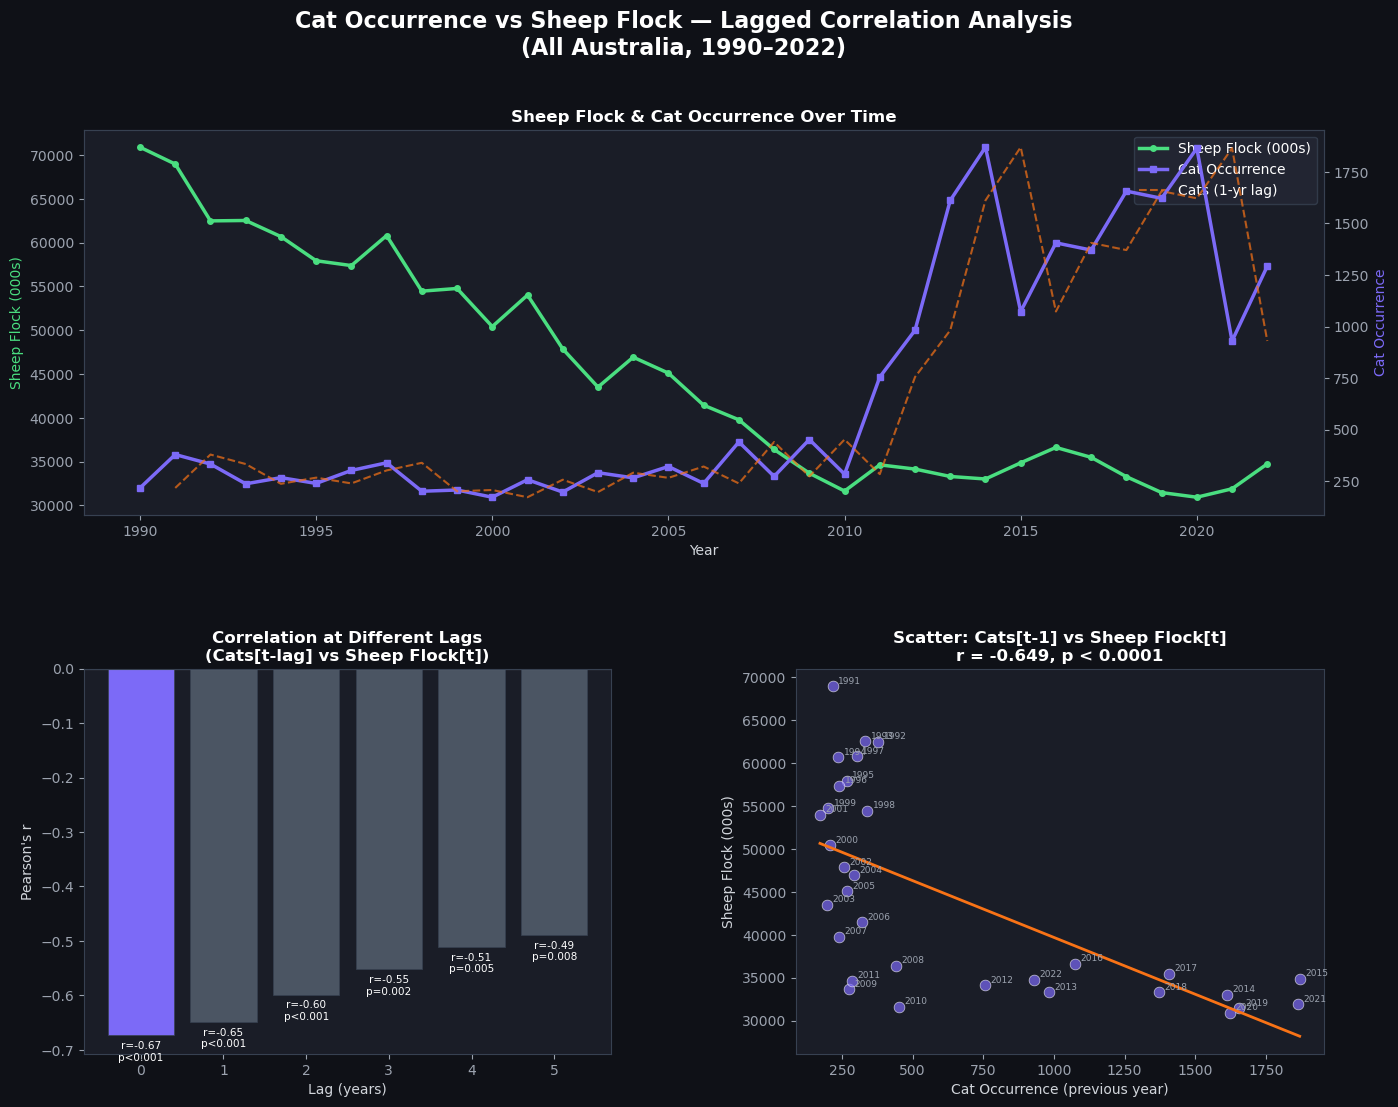

In [ ]:
df = pd.read_csv('../datasets/farm_cat.csv')

aus = df[df['territory'] == 'All Australia'].copy()
aus = aus.sort_values('year').reset_index(drop=True)

aus = aus[['year', 'cats_occurrence_total', 'sheep_flock', 'lambs', 'ewes']].dropna()

aus['cats_lag1'] = aus['cats_occurrence_total'].shift(1)

aus_lag = aus.dropna()

r_no_lag, p_no_lag = stats.pearsonr(aus['cats_occurrence_total'].dropna(), 
                                     aus['sheep_flock'].dropna())

r_lag, p_lag = stats.pearsonr(aus_lag['cats_lag1'], aus_lag['sheep_flock'])
r_lag_lambs, p_lag_lambs = stats.pearsonr(aus_lag['cats_lag1'], aus_lag['lambs'])

lags = range(0, 6)
lag_corrs = []
for lag in lags:
    aus[f'cats_lag{lag}'] = aus['cats_occurrence_total'].shift(lag)
    tmp = aus.dropna()
    if len(tmp) > 5:
        r, p = stats.pearsonr(tmp[f'cats_lag{lag}'], tmp['sheep_flock'])
        lag_corrs.append({'lag': lag, 'r': r, 'p': p})

lag_df = pd.DataFrame(lag_corrs)

fig = plt.figure(figsize=(16, 12), facecolor='#0f1117')
fig.suptitle('Cat Occurrence vs Sheep Flock — Lagged Correlation Analysis\n(All Australia, 1990–2022)', 
             fontsize=16, color='white', fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

DARK = '#0f1117'
CARD = '#1a1d27'
ACCENT1 = '#7c6af7'   # purple - cats
ACCENT2 = '#4ade80'   # green - sheep
ACCENT3 = '#f97316'   # orange - lag line

for ax in [ax1, ax2, ax3]:
    ax.set_facecolor(CARD)
    ax.tick_params(colors='#9ca3af')
    ax.xaxis.label.set_color('#d1d5db')
    ax.yaxis.label.set_color('#d1d5db')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#374151')

ax1_twin = ax1.twinx()
ax1_twin.set_facecolor(CARD)
ax1_twin.tick_params(colors='#9ca3af')
for spine in ax1_twin.spines.values():
    spine.set_edgecolor('#374151')

line1, = ax1.plot(aus['year'], aus['sheep_flock'], color=ACCENT2, linewidth=2.5, 
                   marker='o', markersize=4, label='Sheep Flock (000s)')
line2, = ax1_twin.plot(aus['year'], aus['cats_occurrence_total'], color=ACCENT1, 
                        linewidth=2.5, marker='s', markersize=4, label='Cat Occurrence')

line3, = ax1_twin.plot(aus_lag['year'], aus_lag['cats_lag1'], color=ACCENT3, 
                        linewidth=1.5, linestyle='--', alpha=0.7, label='Cats (1-yr lag)')

ax1.set_xlabel('Year')
ax1.set_ylabel('Sheep Flock (000s)', color=ACCENT2)
ax1_twin.set_ylabel('Cat Occurrence', color=ACCENT1)
ax1.yaxis.label.set_color(ACCENT2)
ax1_twin.yaxis.label.set_color(ACCENT1)
ax1_twin.tick_params(colors='#9ca3af')

lines = [line1, line2, line3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, facecolor='#252836', edgecolor='#374151', 
           labelcolor='white', loc='upper right')
ax1.set_title('Sheep Flock & Cat Occurrence Over Time', fontweight='bold')

colors_bar = [ACCENT1 if abs(r) == lag_df['r'].abs().max() else '#4b5563' for r in lag_df['r']]
bars = ax2.bar(lag_df['lag'], lag_df['r'], color=colors_bar, edgecolor='#374151', linewidth=0.5)
ax2.axhline(0, color='white', linewidth=0.8, alpha=0.5)
ax2.set_xlabel('Lag (years)')
ax2.set_ylabel("Pearson's r")
ax2.set_title('Correlation at Different Lags\n(Cats[t-lag] vs Sheep Flock[t])', fontweight='bold')
ax2.set_xticks(lag_df['lag'])

for _, row in lag_df.iterrows():
    p_str = f"p={row['p']:.3f}" if row['p'] >= 0.001 else "p<0.001"
    ax2.text(row['lag'], row['r'] + (0.02 if row['r'] >= 0 else -0.05), 
             f"r={row['r']:.2f}\n{p_str}", ha='center', va='bottom', 
             fontsize=7.5, color='white')

ax3.scatter(aus_lag['cats_lag1'], aus_lag['sheep_flock'], 
            color=ACCENT1, alpha=0.7, s=60, edgecolors='white', linewidth=0.5)

m, b = np.polyfit(aus_lag['cats_lag1'], aus_lag['sheep_flock'], 1)
x_line = np.linspace(aus_lag['cats_lag1'].min(), aus_lag['cats_lag1'].max(), 100)
ax3.plot(x_line, m * x_line + b, color=ACCENT3, linewidth=2)

for _, row in aus_lag.iterrows():
    ax3.annotate(str(int(row['year'])), (row['cats_lag1'], row['sheep_flock']),
                 textcoords='offset points', xytext=(4, 2), fontsize=6.5, color='#9ca3af')

p_str = f"p = {p_lag:.4f}" if p_lag >= 0.0001 else "p < 0.0001"
ax3.set_title(f'Scatter: Cats[t-1] vs Sheep Flock[t]\nr = {r_lag:.3f}, {p_str}', fontweight='bold')
ax3.set_xlabel('Cat Occurrence (previous year)')
ax3.set_ylabel('Sheep Flock (000s)')

plt.savefig('cat_sheep_lagged_correlation.png', 
            dpi=150, bbox_inches='tight', facecolor=DARK)

print(f"No lag:    r = {r_no_lag:.3f}, p = {p_no_lag:.4f}")
print(f"1-yr lag:  r = {r_lag:.3f}, p = {p_lag:.4f}")
print(f"\nLag correlation table:")
print(lag_df.to_string(index=False))

# First difference estimator - FDE


Intercept:
  Coefficient : -1155.0956
  Std Error   :   508.4006
  t-statistic :    -2.2720
  p-value     :     0.0304

Δ Cats:
  Coefficient :     0.7417
  Std Error   :     1.7019
  t-statistic :     0.4358
  p-value     :     0.6661

R²            : 0.0063
Durbin-Watson : 2.2890  (was 0.33 in original OLS)

Interpretation:
  A 1-unit increase in cat occurrence is associated with a
  0.7 unit change in sheep flock the same year.
  This is NOT statistically significant (p=0.6661).
  → This correlation may have been driven by shared trend.


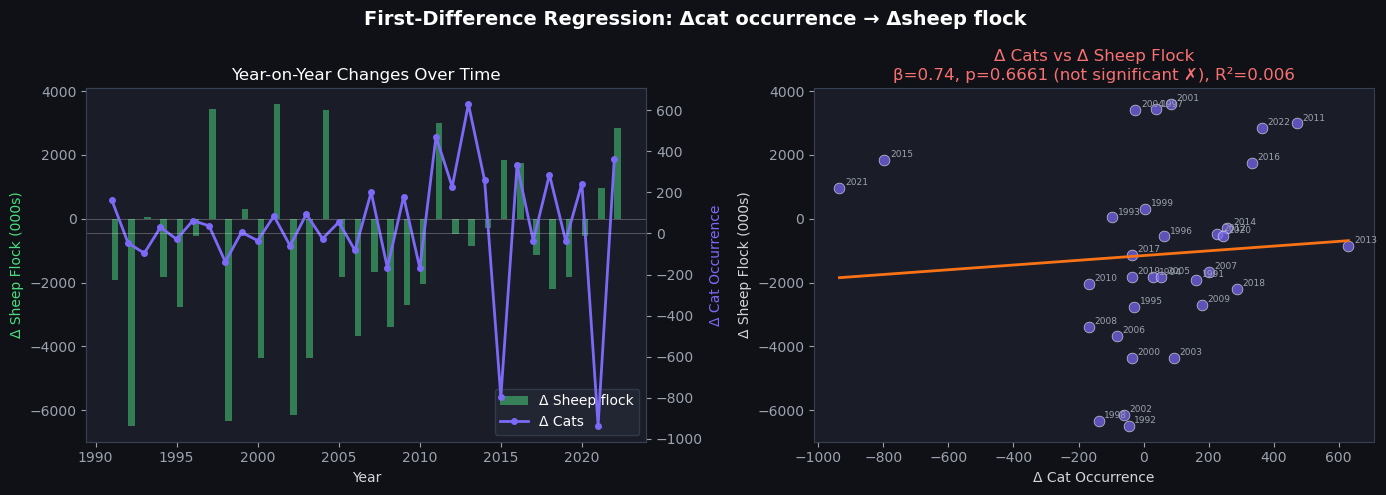

In [ ]:
df = pd.read_csv('../datasets/farm_cat.csv')
aus = df[df['territory'] == 'All Australia'].copy()
aus = aus.sort_values('year').dropna(subset=['cats_occurrence_total', 'sheep_flock'])

aus['d_cats']  = aus['cats_occurrence_total'].diff()
aus['d_sheep'] = aus['sheep_flock'].diff()
fd = aus.dropna(subset=['d_cats', 'd_sheep'])

X_fd  = fd['d_cats'].values
y_fd  = fd['d_sheep'].values
years = fd['year'].values
n     = len(y_fd)

X_mat = np.column_stack([np.ones(n), X_fd])
beta  = np.linalg.lstsq(X_mat, y_fd, rcond=None)[0]
y_pred = X_mat @ beta
resid  = y_fd - y_pred
mse    = np.sum(resid ** 2) / (n - 2)
XtX_inv = np.linalg.inv(X_mat.T @ X_mat)
se     = np.sqrt(np.diag(mse * XtX_inv))
t_stat = beta / se
p_vals = 2 * (1 - stats.t.cdf(np.abs(t_stat), df=n - 2))
r2     = 1 - np.sum(resid**2) / np.sum((y_fd - y_fd.mean())**2)

dw = np.sum(np.diff(resid)**2) / np.sum(resid**2)

labels = ['Intercept', 'Δ Cats']
for i, lab in enumerate(labels):
    print(f"\n{lab}:")
    print(f"  Coefficient : {beta[i]:>10.4f}")
    print(f"  Std Error   : {se[i]:>10.4f}")
    print(f"  t-statistic : {t_stat[i]:>10.4f}")
    print(f"  p-value     : {p_vals[i]:>10.4f}")
print(f"\nR²            : {r2:.4f}")
print(f"Durbin-Watson : {dw:.4f}  (was 0.33 in original OLS)")
print("\nInterpretation:")
print(f"  A 1-unit increase in cat occurrence is associated with a")
print(f"  {beta[1]:.1f} unit change in sheep flock the same year.")
if p_vals[1] < 0.05:
    print(f"  This is statistically significant (p={p_vals[1]:.4f}).")
else:
    print(f"  This is NOT statistically significant (p={p_vals[1]:.4f}).")
    print("  → This correlation may have been driven by shared trend.")

DARK, CARD = '#0f1117', '#1a1d27'
A1, A2, A3 = '#7c6af7', '#4ade80', '#f97316'

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=DARK)
fig.suptitle('First-Difference Regression: Δcat occurrence → Δsheep flock',
             fontsize=14, color='white', fontweight='bold')

for ax in axes:
    ax.set_facecolor(CARD)
    ax.tick_params(colors='#9ca3af')
    ax.xaxis.label.set_color('#d1d5db')
    ax.yaxis.label.set_color('#d1d5db')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#374151')

ax  = axes[0]
ax2 = ax.twinx()
ax2.set_facecolor(CARD)
ax2.tick_params(colors='#9ca3af')
for spine in ax2.spines.values():
    spine.set_edgecolor('#374151')

ax.bar(years,  y_fd,  color=A2, alpha=0.5, label='Δ Sheep flock', width=0.4,
       align='edge')
ax2.plot(years, X_fd, color=A1, linewidth=2, marker='o', markersize=4,
         label='Δ Cats')
ax2.axhline(0, color='white', linewidth=0.6, alpha=0.3)
ax.axhline(0, color='white', linewidth=0.6, alpha=0.3)
ax.set_xlabel('Year')
ax.set_ylabel('Δ Sheep Flock (000s)', color=A2)
ax2.set_ylabel('Δ Cat Occurrence', color=A1)
ax.yaxis.label.set_color(A2)
ax2.yaxis.label.set_color(A1)
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2,
          facecolor='#252836', edgecolor='#374151', labelcolor='white')
ax.set_title('Year-on-Year Changes Over Time')

ax = axes[1]
ax.scatter(X_fd, y_fd, color=A1, alpha=0.7, s=60,
           edgecolors='white', linewidth=0.5)
x_line = np.linspace(X_fd.min(), X_fd.max(), 100)
ax.plot(x_line, beta[0] + beta[1] * x_line, color=A3, linewidth=2)
for xv, yv, yr in zip(X_fd, y_fd, years):
    ax.annotate(str(yr), (xv, yv), textcoords='offset points',
                xytext=(4, 2), fontsize=6.5, color='#9ca3af')
sig = "significant ✓" if p_vals[1] < 0.05 else "not significant ✗"
ax.set_title(f'Δ Cats vs Δ Sheep Flock\n'
             f'β={beta[1]:.2f}, p={p_vals[1]:.4f} ({sig}), R²={r2:.3f}')
ax.title.set_color('#4ade80' if p_vals[1] < 0.05 else '#f87171')
ax.set_xlabel('Δ Cat Occurrence')
ax.set_ylabel('Δ Sheep Flock (000s)')

plt.tight_layout()
plt.savefig('first_difference.png', dpi=150,
            bbox_inches='tight', facecolor=DARK)


# Stat Analysis

In [ ]:
# merged = df.groupby(['year', 'ibraRegion'])['occurrenceCount'].sum().reset_index()


# for state in merged['ibraRegion'].unique():
#     state_df = merged[merged['ibraRegion'] == state]

#     X = sm.add_constant(state_df['year'])
#     y = state_df['occurrenceCount']

#     model = sm.OLS(y, X).fit()
#     print(f"\n{state}")
#     print(model.summary())